# Context-Aware Misinformation Detection — DistilBERT Classifier

**Label convention:** `0 = fake`, `1 = true` (matches your CSV).

**On your question — should title and content be combined?**
Yes, in almost every fake-news benchmark (FakeNewsNet, LIAR, ISOT, etc.) concatenating title + content beats using either alone. Headlines carry a strong, cheap signal (sensational punctuation, ALL CAPS, clickbait phrasing) that the body text dilutes, while the body gives the model the substance to check consistency. This notebook concatenates them as `title + ". " + content` before tokenizing, but Section 6 also gives you a one-line toggle to run title-only or content-only if you want to ablate that decision and confirm it on your own data — with a 300k+ row corpus the gap is usually a few F1 points in favor of combining, so it's worth the 5 minutes to check rather than assume.

## 1. Install & import

In [1]:
!pip uninstall -y -q torchaudio torchvision
!pip install -q transformers datasets accelerate evaluate scikit-learn seaborn matplotlib


In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


## 2. Mount Drive & load data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

INPUT_CSV = "/content/drive/MyDrive/Colab Notebooks/Context-Aware Misinformation Detection/BigDataSet/clean/bd_combined_news.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/Context-Aware Misinformation Detection/BigDataSet/DistilBERT/pickle"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_CSV)
print(df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(63670, 2)


,label,content
0,1,Trump Will Be President - How Alt-Market Predi...
1,0,Listening to This New Podcast Could Save Your ...
2,1,CrossTalk on US election: Criminal in Chief?.2...
3,1,How Will Clinton - Comey Affect Gold Prices?.H...
4,0,Congress Passes One-Week Spending Bill to Aver...


Rows after cleanup: 63670
label
0    0.54638
1    0.45362
Name: proportion, dtype: float64


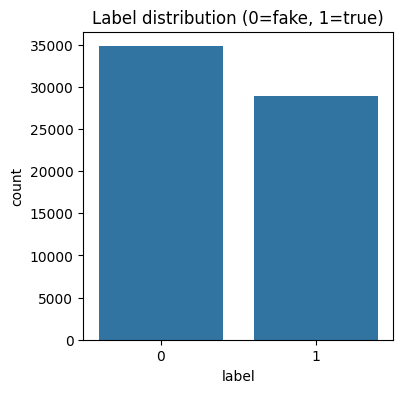

In [4]:
# Basic cleanup: drop rows with missing essential fields, ensure label is int
df = df.dropna(subset=["content", "label"]).copy()
df["label"] = df["label"].astype(int)
df["content"] = df["content"].astype(str).str.strip()

print("Rows after cleanup:", len(df))
print(df["label"].value_counts(normalize=True))

plt.figure(figsize=(4, 4))
sns.countplot(x="label", data=df)
plt.title("Label distribution (0=fake, 1=true)")
plt.xlabel("label")
plt.ylabel("count")
plt.show()


## 3. Stratified train / val / test split

`test_size=0.3`, `stratify=True` for the held-out test set. additionally carved a small stratified validation slice out of the remaining 70% so the Trainer can do early stopping / pick the best checkpoint without ever touching the test set.

In [5]:
train_val_df, test_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=SEED
)

train_df, val_df = train_test_split(
    train_val_df, test_size=0.1, stratify=train_val_df["label"], random_state=SEED
)

print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, d["label"].value_counts(normalize=True).to_dict())


train: (40112, 2) val: (4457, 2) test: (19101, 2)
train {0: 0.5463950937375349, 1: 0.4536049062624651}
val {0: 0.5463316131927305, 1: 0.45366838680726945}
test {0: 0.5463588293806607, 1: 0.4536411706193393}


## 5. Tokenize

In [ ]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256  # bump to 512 if you want the full article body; slower + more memory

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def to_hf_dataset(d):
    ds = Dataset.from_pandas(d[["content", "label"]].reset_index(drop=True))
    return ds.map(
        lambda batch: tokenizer(
            batch["content"], truncation=True, padding="max_length", max_length=MAX_LENGTH
        ),
        batched=True,
    )

train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)
test_ds = to_hf_dataset(test_df)

train_ds = train_ds.rename_column("label", "labels")
val_ds = val_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

cols = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)


Map:   0%|          | 0/40112 [00:00<?, ? examples/s]

## 6. Model + Trainer

Parameters below are the widely-used, well-behaved defaults for fine-tuning DistilBERT on binary text classification (2–4 epochs, lr 2e-5, linear warmup, weight decay 0.01). They're a strong starting point for a few hundred thousand rows; if you have GPU budget to spare, a quick Optuna/Ray Tune sweep over `learning_rate` and `num_train_epochs` is the natural next step (see the "extend" notes at the end).

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

training_args = TrainingArguments(
    output_dir="/content/dbert_ckpts",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


In [ ]:
train_result = trainer.train()


## 7. Training curves

In [ ]:
log_history = trainer.state.log_history
train_loss = [(e["step"], e["loss"]) for e in log_history if "loss" in e]
eval_loss = [(e["epoch"], e["eval_loss"]) for e in log_history if "eval_loss" in e]
eval_f1 = [(e["epoch"], e["eval_f1"]) for e in log_history if "eval_f1" in e]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if train_loss:
    steps, losses = zip(*train_loss)
    axes[0].plot(steps, losses, label="train loss")
if eval_loss:
    epochs, losses = zip(*eval_loss)
    axes[0].plot([e for e in epochs], losses, marker="o", label="val loss")
axes[0].set_xlabel("step / epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Loss")
axes[0].legend()

if eval_f1:
    epochs, f1s = zip(*eval_f1)
    axes[1].plot(epochs, f1s, marker="o", color="green")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("F1")
axes[1].set_title("Validation F1")

plt.tight_layout()
plt.show()


## 8. Final evaluation on the held-out test set

In [ ]:
pred_output = trainer.predict(test_ds)
logits = pred_output.predictions
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]  # P(label=1 / true)
y_pred = np.argmax(logits, axis=-1)
y_true = pred_output.label_ids

print(classification_report(y_true, y_pred, target_names=["fake (0)", "true (1)"]))


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["fake", "true"], yticklabels=["fake", "true"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_true, probs)
axes[2].plot(rec, prec)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


## 9. Save the model

Two things get saved:
1. `save_pretrained` — the standard, robust Hugging Face format. **Use this to reload the model** — it's portable across transformers versions and doesn't depend on pickle's fragile class-reference behavior.
2. A `.pkl` at the exact path you asked for, containing the model's `state_dict`, config, and the tokenizer. This satisfies the "pickle file" requirement but note that raw `torch.nn.Module` pickling is version-sensitive — if you ever hit an unpickling error after a library upgrade, fall back to the `save_pretrained` folder instead.

In [ ]:
# 1) Robust HF format (recommended for reloading)
hf_dir = os.path.join(OUTPUT_DIR, "hf_model")
os.makedirs(hf_dir, exist_ok=True)
trainer.save_model(hf_dir)
tokenizer.save_pretrained(hf_dir)

# 2) Pickle file at the requested location
pickle_path = os.path.join(OUTPUT_DIR, "distilbert_fake_news.pkl")
artifact = {
    "model_state_dict": model.state_dict(),
    "model_config": model.config.to_dict(),
    "tokenizer": tokenizer,
    "max_length": MAX_LENGTH,
    "text_mode": TEXT_MODE,
    "label_map": {0: "fake", 1: "true"},
}
with open(pickle_path, "wb") as f:
    pickle.dump(artifact, f)

print("Saved HF model to:", hf_dir)
print("Saved pickle to:", pickle_path)


## 10. Inference helper (reload + predict on new text)

In [ ]:
def load_from_pickle(pkl_path):
    with open(pkl_path, "rb") as f:
        art = pickle.load(f)
    m = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    )
    m.load_state_dict(art["model_state_dict"])
    m.to(device).eval()
    return m, art["tokenizer"], art["max_length"]

def predict(text, model_, tok_, max_len_):
    inputs = tok_(text, truncation=True, padding="max_length",
                  max_length=max_len_, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model_(**inputs).logits
    p = torch.softmax(logits, dim=1).cpu().numpy()[0]
    label = int(np.argmax(p))
    return {"label": label, "meaning": "true" if label == 1 else "fake", "confidence": float(p[label])}

# Example:
# loaded_model, loaded_tok, loaded_len = load_from_pickle(pickle_path)
# print(predict("Some headline. Some article body...", loaded_model, loaded_tok, loaded_len))
